In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [1]:
#| echo: true
import torch
import networkx as nx
import matplotlib.pyplot as plt

Creating a toy graph.

In [2]:
#| echo: true
N = 10
d = 3
G = nx.cycle_graph(N)

A_0 = torch.tensor(nx.to_numpy_array(G), dtype=torch.float32)
X_0 = torch.ones((N, d), dtype=torch.float32)

Using a Variance Preserving SDE (VP-SDE) to corrupt the data.

In [3]:
#| echo: true
T = 1000
betas = torch.linspace(1e-4, 0.02, T)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

def corrupt_graph(A_0, X_0, t):
    alpha_bar = alphas_cumprod[t]

    noise_X = torch.randn_like(X_0)

    noise_A_raw = torch.randn_like(A_0)
    noise_A_upper = torch.triu(noise_A_raw, diagonal=1)
    noise_A = noise_A_upper + noise_A_upper.T

    X_t = torch.sqrt(alpha_bar) * X_0 + torch.sqrt(1 - alpha_bar) * noise_X
    A_t = torch.sqrt(alpha_bar) * A_0 + torch.sqrt(1 - alpha_bar) * noise_A

    return X_t, A_t

Simulating a forward process.

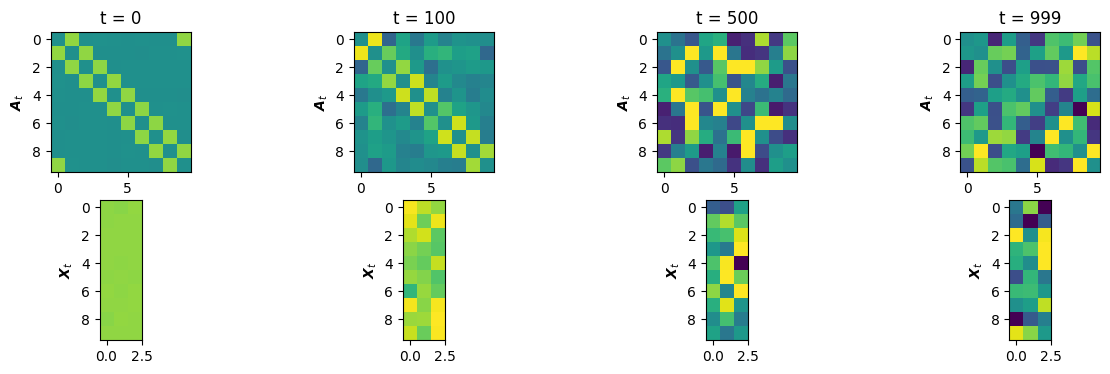

In [11]:
#| echo: true
timesteps = [0, 100, 500, 999]
fig, axs = plt.subplots(2, len(timesteps), figsize=(15, 4))

for i, t in enumerate(timesteps):
    X_t, A_t = corrupt_graph(A_0, X_0, t)

    axs[0, i].imshow(A_t.numpy(), cmap='viridis', vmin=-1.5, vmax=1.5)
    axs[1, i].imshow(X_t.numpy(), cmap='viridis', vmin=-1.5, vmax=1.5)

    axs[0, i].set_title(f"t = {t}")
    axs[0, i].set_ylabel(r"$\boldsymbol{A}_t$")
    axs[1, i].set_ylabel(r"$\boldsymbol{X}_t$")

plt.show()